# FIAP — Dynamic Programming
## Checkpoint 2 — Sistema de rotas de metrô


| Integrante | RA |
|---|---|
| Vitor Alcantara | RM565885 |

In [8]:
import time, tracemalloc, functools
import pandas as pd
import matplotlib.pyplot as plt
import folium
from IPython.display import display


## 2. Fatores de horário

In [9]:
def fator_horario(horario: float) -> float:
    if 5 <= horario < 7:
        return 0.6
    if 7 <= horario < 9:
        return 1.5
    if 9 <= horario < 17:
        return 1.0
    if 17 <= horario < 20:
        return 2.0
    return 0.8

horario_partida = 18
print(f"Horário de partida: {horario_partida}h | Fator aplicado: {fator_horario(horario_partida)}")


Horário de partida: 18h | Fator aplicado: 2.0


## 3. Modelagem dos grafos

In [10]:
def add_edge(grafo, origem, destino, peso):
    # Grafo dirigido: aresta no sentido da consulta origem -> destino.
    grafo.setdefault(origem, []).append((destino, peso))
    grafo.setdefault(destino, [])

def construir_grafo(arestas):
    grafo = {}
    for origem, destino, peso in arestas:
        add_edge(grafo, origem, destino, peso)
    return grafo

def validar_grafo(nome, grafo, origem, destino):
    assert len(grafo) >= 15
    assert origem in grafo and destino in grafo
    print(f"{nome}: {len(grafo)} estações | origem: {origem} | destino: {destino}")

beijing_edges = [
    ("Sihui East","Sihui",3),("Sihui","Dawanglu",4),("Dawanglu","Guomao",3),
    ("Guomao","Yong'anli",2),("Yong'anli","Jianguomen",3),("Jianguomen","Dongdan",3),
    ("Dongdan","Wangfujing",2),("Wangfujing","Tiananmen East",2),("Tiananmen East","Tiananmen West",2),
    ("Tiananmen West","Xidan",3),("Xidan","Fuxingmen",3),("Fuxingmen","Fuchengmen",3),
    ("Fuchengmen","Chegongzhuang",2),("Chegongzhuang","Xizhimen",3),
    ("Jianguomen","Beijing Railway Station",3),("Beijing Railway Station","Chongwenmen",3),
    ("Chongwenmen","Qianmen",3),("Qianmen","Xuanwumen",3),("Xuanwumen","Xidan",3),
    ("Xuanwumen","Caishikou",3),("Caishikou","Ping'anli",5),("Ping'anli","Xizhimen",4),
    ("Guomao","Hujialou",3),("Hujialou","Sanyuanqiao",5),("Sanyuanqiao","Shaoyaoju",4),
    ("Shaoyaoju","Xitucheng",6),("Xitucheng","Haidian Huangzhuang",3),("Haidian Huangzhuang","Xizhimen",6),
]

sf_edges = [
    ("Dublin/Pleasanton","West Dublin/Pleasanton",4),("West Dublin/Pleasanton","Castro Valley",8),
    ("Castro Valley","Bay Fair",6),("Bay Fair","San Leandro",4),("San Leandro","Coliseum",5),
    ("Coliseum","Fruitvale",4),("Fruitvale","Lake Merritt",4),("Lake Merritt","West Oakland",5),
    ("West Oakland","Embarcadero",7),("Embarcadero","Montgomery St",2),("Montgomery St","Powell St",2),
    ("Powell St","Civic Center/UN Plaza",2),("Civic Center/UN Plaza","16th St Mission",3),
    ("16th St Mission","24th St Mission",3),("24th St Mission","Glen Park",4),("Glen Park","Balboa Park",3),
    ("Balboa Park","Daly City",3),("Lake Merritt","12th St Oakland City Center",3),
    ("12th St Oakland City Center","19th St Oakland",2),("19th St Oakland","West Oakland",4),
    ("Bay Fair","Hayward",4),("Hayward","South Hayward",4),("South Hayward","Union City",5),("Union City","Fremont",5),
]

sp_edges = [
    ("Tucuruvi","Parada Inglesa",3),("Parada Inglesa","Jardim São Paulo-Ayrton Senna",3),
    ("Jardim São Paulo-Ayrton Senna","Santana",3),("Santana","Carandiru",2),("Carandiru","Portuguesa-Tietê",2),
    ("Portuguesa-Tietê","Armênia",2),("Armênia","Tiradentes",2),("Tiradentes","Luz",3),
    ("Luz","São Bento",2),("São Bento","Sé",2),("Sé","Liberdade",2),("Liberdade","São Joaquim",2),
    ("São Joaquim","Vergueiro",2),("Vergueiro","Paraíso",2),("Paraíso","Ana Rosa",2),
    ("Ana Rosa","Vila Mariana",2),("Vila Mariana","Santa Cruz",3),
    ("Paraíso","Brigadeiro",2),("Brigadeiro","Consolação",4),("Consolação","Paulista",1),
    ("Paulista","República",3),("República","Luz",3),("Ana Rosa","Chácara Klabin",3),("Chácara Klabin","Santa Cruz",3),
    ("Santa Cruz","Hospital São Paulo",2),("Hospital São Paulo","AACD-Servidor",2),("AACD-Servidor","Moema",3),
    ("Moema","Eucaliptos",3),("Eucaliptos","Campo Belo",3),("Campo Belo","Brooklin",3),
    ("Brooklin","Borba Gato",3),("Borba Gato","Alto da Boa Vista",2),("Alto da Boa Vista","Adolfo Pinheiro",2),
    ("Adolfo Pinheiro","Largo Treze",3),("Largo Treze","Santo Amaro",3),("Santo Amaro","Giovanni Gronchi",4),
    ("Giovanni Gronchi","Vila das Belezas",3),("Vila das Belezas","Campo Limpo",3),("Campo Limpo","Capão Redondo",4),
]

cidades = {
    "Beijing": {"grafo": construir_grafo(beijing_edges), "origem": "Sihui East", "destino": "Xizhimen"},
    "San Francisco": {"grafo": construir_grafo(sf_edges), "origem": "Dublin/Pleasanton", "destino": "Daly City"},
    "São Paulo": {"grafo": construir_grafo(sp_edges), "origem": "Tucuruvi", "destino": "Capão Redondo"},
}

for nome, dados in cidades.items():
    validar_grafo(nome, dados["grafo"], dados["origem"], dados["destino"])


Beijing: 26 estações | origem: Sihui East | destino: Xizhimen
San Francisco: 24 estações | origem: Dublin/Pleasanton | destino: Daly City
São Paulo: 38 estações | origem: Tucuruvi | destino: Capão Redondo


## 4. Algoritmos recursivos

In [ ]:
def menor_caminho_sem_memo(grafo, origem, destino, horario, visitados=frozenset()):
    if origem == destino:
        return 0, (destino,)
    melhor_custo = float("inf")
    melhor_caminho = tuple()
    fator = fator_horario(horario)
    for vizinho, peso in grafo.get(origem, []):
        if vizinho not in visitados:
            custo_resto, caminho_resto = menor_caminho_sem_memo(grafo, vizinho, destino, horario, visitados | {origem})
            if caminho_resto:
                custo_total = fator * peso + custo_resto
                if custo_total < melhor_custo:
                    melhor_custo = custo_total
                    melhor_caminho = (origem,) + caminho_resto
    return melhor_custo, melhor_caminho

def criar_solver_memo(grafo):
    
    # O @functools.Iru_cache salva o resultado em cache
    @functools.lru_cache(maxsize=None)

    def menor_caminho_memo(origem, destino, horario, visitados=frozenset()):
        if origem == destino:
            return 0, (destino,)
        melhor_custo = float("inf")
        melhor_caminho = tuple()
        fator = fator_horario(horario)
        for vizinho, peso in grafo.get(origem, []):
            if vizinho not in visitados:
                custo_resto, caminho_resto = menor_caminho_memo(vizinho, destino, horario, visitados | {origem})
                if caminho_resto:
                    custo_total = fator * peso + custo_resto
                    if custo_total < melhor_custo:
                        melhor_custo = custo_total
                        melhor_caminho = (origem,) + caminho_resto
        return melhor_custo, melhor_caminho
    return menor_caminho_memo

def maior_caminho_simples(grafo, origem, destino, horario, visitados=None):
    if visitados is None:
        visitados = set()
    if origem == destino:
        return 0, (destino,)
    visitados.add(origem)
    maior_custo = -float("inf")
    maior_caminho = tuple()
    fator = fator_horario(horario)
    for vizinho, peso in grafo.get(origem, []):
        if vizinho not in visitados:
            custo_resto, caminho_resto = maior_caminho_simples(grafo, vizinho, destino, horario, visitados)
            if caminho_resto:
                custo_total = fator * peso + custo_resto
                if custo_total > maior_custo:
                    maior_custo = custo_total
                    maior_caminho = (origem,) + caminho_resto
    visitados.remove(origem)
    return maior_custo, maior_caminho


## 5. Análise de desempenho

In [12]:
def medir_execucao(func, *args):
    tracemalloc.start()
    inicio = time.perf_counter()
    resultado = func(*args)
    fim = time.perf_counter()
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return resultado, fim - inicio, pico / 1024

resultados = []
rotas = {}
for cidade, dados in cidades.items():
    grafo, origem, destino = dados["grafo"], dados["origem"], dados["destino"]
    (custo_sem, caminho_sem), tempo_sem, mem_sem = medir_execucao(menor_caminho_sem_memo, grafo, origem, destino, horario_partida)
    solver = criar_solver_memo(grafo)
    (custo_memo, caminho_memo), tempo_memo, mem_memo = medir_execucao(solver, origem, destino, horario_partida, frozenset())
    cache = solver.cache_info()
    (custo_longo, caminho_longo), tempo_longo, mem_longo = medir_execucao(maior_caminho_simples, grafo, origem, destino, horario_partida)
    rotas[cidade] = {"curto": caminho_memo, "longo": caminho_longo}
    resultados.extend([
        {"Cidade": cidade, "Algoritmo": "Mais curto sem memoização", "Custo": round(custo_sem, 2), "Estações": len(caminho_sem), "Tempo (s)": tempo_sem, "Memória KB": mem_sem, "Cache hits": None, "Cache misses": None, "Caminho": " → ".join(caminho_sem)},
        {"Cidade": cidade, "Algoritmo": "Mais curto com memoização", "Custo": round(custo_memo, 2), "Estações": len(caminho_memo), "Tempo (s)": tempo_memo, "Memória KB": mem_memo, "Cache hits": cache.hits, "Cache misses": cache.misses, "Caminho": " → ".join(caminho_memo)},
        {"Cidade": cidade, "Algoritmo": "Mais longo simples", "Custo": round(custo_longo, 2), "Estações": len(caminho_longo), "Tempo (s)": tempo_longo, "Memória KB": mem_longo, "Cache hits": None, "Cache misses": None, "Caminho": " → ".join(caminho_longo)},
    ])

df_resultados = pd.DataFrame(resultados)
df_resultados


,Cidade,Algoritmo,Custo,Estações,Tempo (s),Memória KB,Cache hits,Cache misses,Caminho
0,Beijing,Mais curto sem memoização,74.0,10,0.000185,7.492188,NaN,NaN,Sihui East → Sihui → Dawanglu → Guomao → Hujia...
1,Beijing,Mais curto com memoização,74.0,10,0.000174,18.976562,0.0,33.0,Sihui East → Sihui → Dawanglu → Guomao → Hujia...
2,Beijing,Mais longo simples,82.0,15,0.000111,2.687500,NaN,NaN,Sihui East → Sihui → Dawanglu → Guomao → Yong'...
3,San Francisco,Mais curto sem memoização,138.0,18,0.000191,12.828125,NaN,NaN,Dublin/Pleasanton → West Dublin/Pleasanton → C...
4,San Francisco,Mais curto com memoização,138.0,18,0.000206,25.468750,0.0,34.0,Dublin/Pleasanton → West Dublin/Pleasanton → C...
5,San Francisco,Mais longo simples,146.0,20,0.000102,3.765625,NaN,NaN,Dublin/Pleasanton → West Dublin/Pleasanton → C...
6,São Paulo,Mais curto sem memoização,164.0,33,0.000330,29.390625,NaN,NaN,Tucuruvi → Parada Inglesa → Jardim São Paulo-A...
7,São Paulo,Mais curto com memoização,164.0,33,0.000340,63.375000,0.0,54.0,Tucuruvi → Parada Inglesa → Jardim São Paulo-A...
8,São Paulo,Mais longo simples,166.0,33,0.000135,6.117188,NaN,NaN,Tucuruvi → Parada Inglesa → Jardim São Paulo-A...


## 6. Tabela e gráficos comparativos

,Cidade,Algoritmo,Custo,Estações,Tempo (s),Memória KB,Cache hits,Cache misses
0,Beijing,Mais curto sem memoização,74.0,10,0.000185,7.492188,NaN,NaN
1,Beijing,Mais curto com memoização,74.0,10,0.000174,18.976562,0.0,33.0
3,San Francisco,Mais curto sem memoização,138.0,18,0.000191,12.828125,NaN,NaN
4,San Francisco,Mais curto com memoização,138.0,18,0.000206,25.468750,0.0,34.0
6,São Paulo,Mais curto sem memoização,164.0,33,0.000330,29.390625,NaN,NaN
7,São Paulo,Mais curto com memoização,164.0,33,0.000340,63.375000,0.0,54.0


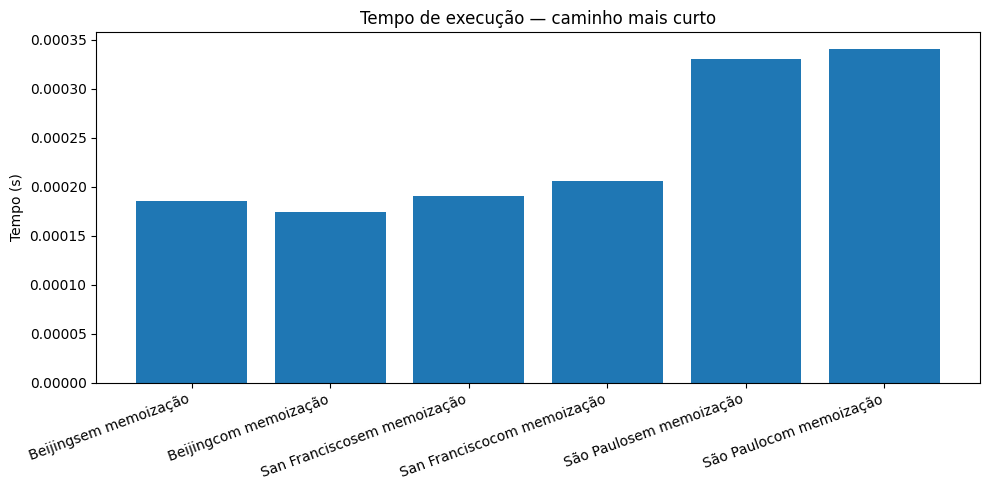

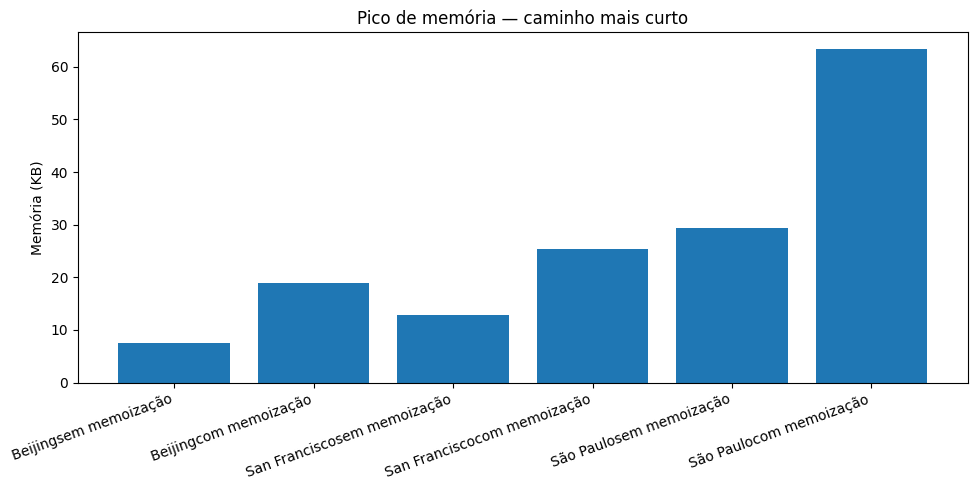

In [13]:
df_comparativo = df_resultados[df_resultados["Algoritmo"].str.contains("Mais curto")].copy()
display(df_comparativo[["Cidade", "Algoritmo", "Custo", "Estações", "Tempo (s)", "Memória KB", "Cache hits", "Cache misses"]])

plt.figure(figsize=(10, 5))
labels = df_comparativo["Cidade"] + "" + df_comparativo["Algoritmo"].str.replace("Mais curto ", "", regex=False)
plt.bar(labels, df_comparativo["Tempo (s)"])
plt.title("Tempo de execução — caminho mais curto")
plt.ylabel("Tempo (s)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(labels, df_comparativo["Memória KB"])
plt.title("Pico de memória — caminho mais curto")
plt.ylabel("Memória (KB)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 7. Visualização com Folium

In [14]:
# Gera os mapas HTML com Folium.
coords = {
    "Sihui East": (39.9085,116.5153), "Sihui": (39.9088,116.4957), "Dawanglu": (39.9084,116.4772), "Guomao": (39.9085,116.4618), "Xizhimen": (39.9402,116.3554),
    "Dublin/Pleasanton": (37.7017,-121.8992), "Bay Fair": (37.6971,-122.1265), "West Oakland": (37.8049,-122.2951), "Embarcadero": (37.7929,-122.3971), "Daly City": (37.7061,-122.4691),
    "Tucuruvi": (-23.4801,-46.6033), "Luz": (-23.5361,-46.6337), "Paraíso": (-23.5750,-46.6408), "Santa Cruz": (-23.5991,-46.6367), "Capão Redondo": (-23.6591,-46.7680),
}

def criar_mapa_resumido(cidade, dados):
    origem, destino = dados["origem"], dados["destino"]
    caminho = rotas[cidade]["curto"]
    pontos = [coords[e] for e in caminho if e in coords]
    mapa = folium.Map(location=pontos[0] if pontos else [0,0], zoom_start=10)
    if len(pontos) >= 2:
        folium.PolyLine(pontos, weight=6, opacity=0.9, tooltip="Caminho mais curto").add_to(mapa)
    for e in caminho:
        if e in coords:
            cor = "green" if e == origem else "red" if e == destino else "blue"
            folium.CircleMarker(coords[e], radius=5, color=cor, fill=True, popup=e).add_to(mapa)
    arquivo = f"mapa_{cidade.lower().replace(' ', '_').replace('ã','a')}.html"
    mapa.save(arquivo)
    return mapa

for cidade, dados in cidades.items():
    print(f"Mapa gerado para {cidade}")
    display(criar_mapa_resumido(cidade, dados))


Mapa gerado para Beijing


Mapa gerado para San Francisco


Mapa gerado para São Paulo
